# Práctica: mediapipe en Python

**Materia:** Recuperación de la Información

`mediapipe` es un framework de Google para construir soluciones de **percepción por computadora en tiempo real** (rostro, manos, cuerpo, objetos), basado en modelos de machine learning ya entrenados.

## ¿Para qué sirve?

`mediapipe` permite **detectar y rastrear** elementos en imágenes o video en tiempo real: rostros, puntos de referencia faciales (*face mesh*), manos, poses corporales, segmentación de personas, entre otros, sin necesidad de entrenar un modelo propio. Es muy usado en filtros de video, control por gestos, análisis de movimiento y extracción de información visual estructurada a partir de imágenes.

## ¿Cómo funciona?

1. Cada tarea (detección de rostro, manos, pose, etc.) usa un **modelo de red neuronal ya entrenado** (formato `.tflite`) que MediaPipe ejecuta de forma eficiente en CPU o GPU.
2. La imagen de entrada se procesa a través de un **pipeline** (grafo de procesamiento) que primero localiza la región de interés (por ejemplo, dónde está el rostro) y luego aplica un segundo modelo más fino sobre esa región (por ejemplo, para ubicar los 468 puntos característicos del rostro).
3. El resultado son **coordenadas normalizadas** (landmarks) de los puntos detectados, que se pueden dibujar sobre la imagen original o usarse como datos numéricos para análisis posteriores.

## ¿Qué tipo de detecciones se pueden realizar?

- **Detección de rostros** (`face_detection`): ubica la posición y el tamaño de cada rostro en la imagen.
- **Malla facial** (`face_mesh`): 468 puntos de referencia que describen la forma detallada del rostro (ojos, cejas, labios, contorno).
- **Detección de manos** (`hands`): 21 puntos por mano, útil para reconocimiento de gestos.
- **Estimación de pose corporal** (`pose`): puntos de articulaciones del cuerpo completo.
- **Segmentación de personas** (`selfie_segmentation`): separa a una persona del fondo.

## Ejemplo simple

Como no contamos con una cámara ni con acceso a internet para descargar una foto de ejemplo, usamos una fotografía real ya incluida en la librería `scikit-image` (la conocida imagen "astronaut", que sí muestra un rostro humano real), sobre la cual aplicamos detección de rostro y malla facial.

Version de mediapipe: 0.10.9


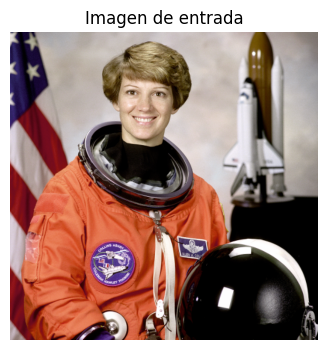

Dimensiones: (512, 512, 3)


In [1]:
import mediapipe as mp
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

print('Version de mediapipe:', mp.__version__)

img = data.astronaut()  # imagen RGB de muestra incluida en scikit-image
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title('Imagen de entrada')
plt.axis('off')
plt.show()
print('Dimensiones:', img.shape)

### Detección de rostro

Rostros detectados: 1
  Confianza de la deteccion: 0.91


E0000 00:00:1783093688.711809       9 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1783093688.711942       9 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


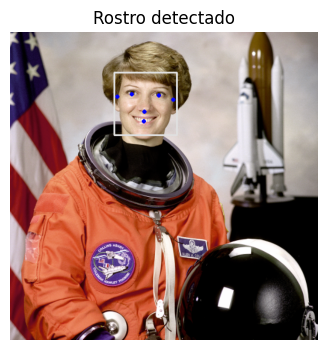

In [2]:
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

img_deteccion = img.copy()
with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as fd:
    resultados = fd.process(img)
    n_rostros = len(resultados.detections) if resultados.detections else 0
    print('Rostros detectados:', n_rostros)
    if resultados.detections:
        for det in resultados.detections:
            mp_drawing.draw_detection(img_deteccion, det)
            score = det.score[0]
            print(f'  Confianza de la deteccion: {score:.2f}')

plt.figure(figsize=(4,4))
plt.imshow(img_deteccion)
plt.title('Rostro detectado')
plt.axis('off')
plt.show()

### Malla facial (Face Mesh)

Ahora ubicamos los 468 puntos de referencia que describen la forma del rostro.

E0000 00:00:1783093689.013291       9 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1783093689.013386       9 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1783093689.013400       9 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)


Numero de puntos (landmarks) detectados: 478
Coordenada normalizada de un punto de referencia (nariz): x=0.436, y=0.254, z=-0.045


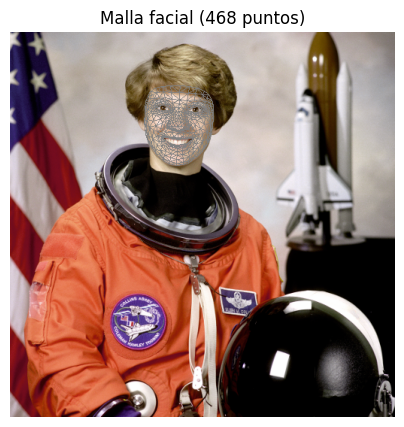

In [3]:
mp_face_mesh = mp.solutions.face_mesh
mp_styles = mp.solutions.drawing_styles

img_malla = img.copy()
with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5) as fm:
    resultados2 = fm.process(img)
    if resultados2.multi_face_landmarks:
        for landmarks in resultados2.multi_face_landmarks:
            print('Numero de puntos (landmarks) detectados:', len(landmarks.landmark))
            mp_drawing.draw_landmarks(
                image=img_malla,
                landmark_list=landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_styles.get_default_face_mesh_tesselation_style())

            # Ejemplo de dato numerico: coordenadas del primer landmark (punta de la nariz aprox. es el indice 1)
            punto_nariz = landmarks.landmark[1]
            print(f'Coordenada normalizada de un punto de referencia (nariz): x={punto_nariz.x:.3f}, y={punto_nariz.y:.3f}, z={punto_nariz.z:.3f}')
    else:
        print('No se detecto malla facial')

plt.figure(figsize=(5,5))
plt.imshow(img_malla)
plt.title('Malla facial (468 puntos)')
plt.axis('off')
plt.show()

## Conclusión

Con unas cuantas líneas de código, `mediapipe` convirtió una imagen en **datos estructurados**: la posición y confianza de un rostro detectado, y las coordenadas exactas de 468 puntos que describen su forma. Esa es la idea central de la visión por computadora aplicada a recuperación de información: transformar contenido visual en datos que se pueden medir, comparar y consultar.